In [2]:
#import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, f1_score, roc_auc_score, roc_curve, accuracy_score, log_loss

In [3]:
#import dataset
bm = pd.read_csv("bank-marketing.csv", sep=";")
print(bm.head(10))
bm.shape

   age          job  marital            education  default housing loan  \
0   56    housemaid  married             basic.4y       no      no   no   
1   57     services  married          high.school  unknown      no   no   
2   37     services  married          high.school       no     yes   no   
3   40       admin.  married             basic.6y       no      no   no   
4   56     services  married          high.school       no      no  yes   
5   45     services  married             basic.9y  unknown      no   no   
6   59       admin.  married  professional.course       no      no   no   
7   41  blue-collar  married              unknown  unknown      no   no   
8   24   technician   single  professional.course       no     yes   no   
9   25     services   single          high.school       no     yes   no   

     contact month day_of_week  ...  campaign  pdays  previous     poutcome  \
0  telephone   may         mon  ...         1    999         0  nonexistent   
1  telephone   m

(41188, 21)

In [4]:
#EDA
print(bm.isnull().sum())
print(bm.duplicated().sum())

age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64
12


In [5]:
#remove disguised missing values
bm.replace('unknown', np.nan, inplace=True)
bm.replace('nonexistent', np.nan, inplace=True)
bm.replace('?', np.nan, inplace=True)

<Axes: xlabel='contact'>

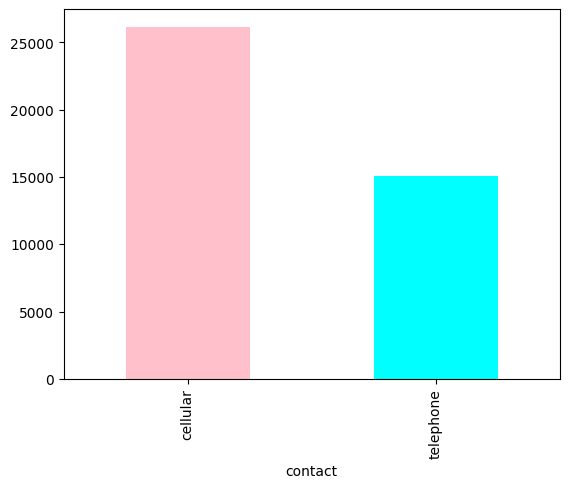

In [6]:
#visualize contact distribution
bm["contact"].value_counts().plot(kind="bar", color=["pink", "cyan", "magenta"])

<Axes: xlabel='month'>

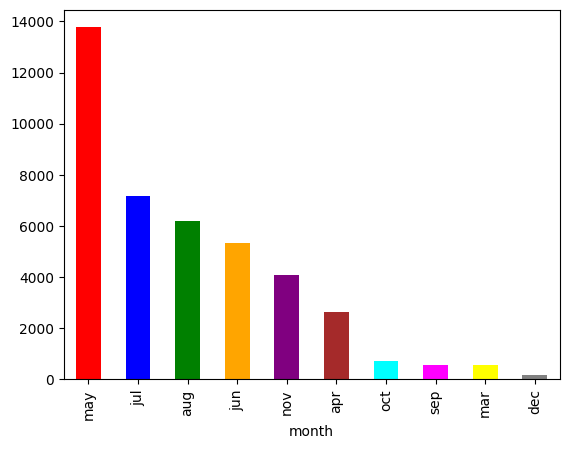

In [7]:
#visualize month distribution
bm["month"].value_counts().plot(kind="bar", color=["red", "blue", "green", "orange", "purple", "brown", "cyan", "magenta", "yellow", "grey", "black", "pink"])

<Axes: xlabel='day_of_week'>

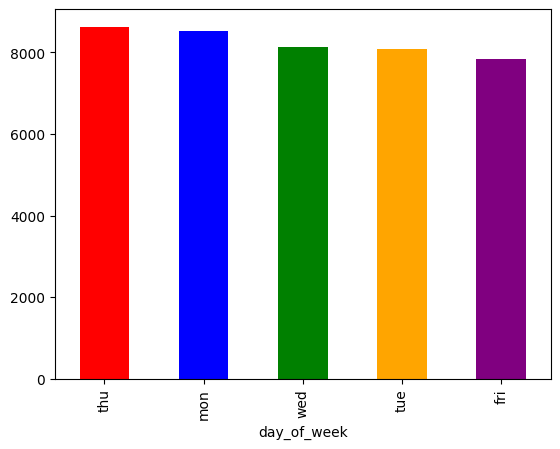

In [8]:
#visualize day of week distribution
bm["day_of_week"].value_counts().plot(kind="bar", color=["red", "blue", "green", "orange", "purple", "brown", "cyan"])

<Axes: xlabel='loan'>

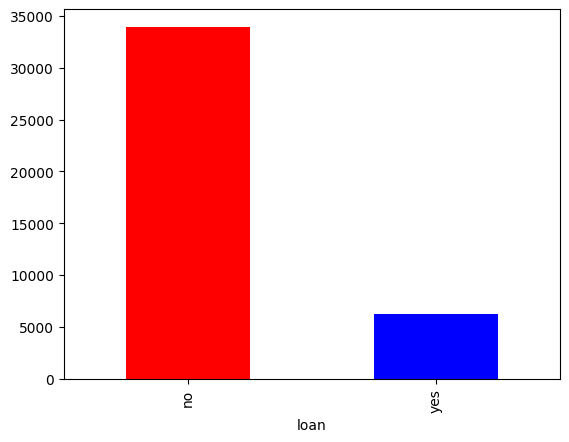

In [9]:
#visualize loan distribution
bm["loan"].value_counts().plot(kind="bar", color=["red", "blue", "green", "orange"])

In [10]:
#drop redundant features
bm.drop(["poutcome", "default", "previous", "pdays"], axis=1, inplace=True)

In [11]:
#check for missing values
bm.isna().sum()

age                  0
job                330
marital             80
education         1731
housing            990
loan               990
contact              0
month                0
day_of_week          0
duration             0
campaign             0
emp.var.rate         0
cons.price.idx       0
cons.conf.idx        0
euribor3m            0
nr.employed          0
y                    0
dtype: int64

In [12]:
#check for missing values again after replacing disguised missing values
bm.isnull().sum()

age                  0
job                330
marital             80
education         1731
housing            990
loan               990
contact              0
month                0
day_of_week          0
duration             0
campaign             0
emp.var.rate         0
cons.price.idx       0
cons.conf.idx        0
euribor3m            0
nr.employed          0
y                    0
dtype: int64

In [13]:
bm.dropna(inplace=True)

In [14]:
#final check of the dataset
bm.info()

<class 'pandas.core.frame.DataFrame'>
Index: 38245 entries, 0 to 41187
Data columns (total 17 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             38245 non-null  int64  
 1   job             38245 non-null  object 
 2   marital         38245 non-null  object 
 3   education       38245 non-null  object 
 4   housing         38245 non-null  object 
 5   loan            38245 non-null  object 
 6   contact         38245 non-null  object 
 7   month           38245 non-null  object 
 8   day_of_week     38245 non-null  object 
 9   duration        38245 non-null  int64  
 10  campaign        38245 non-null  int64  
 11  emp.var.rate    38245 non-null  float64
 12  cons.price.idx  38245 non-null  float64
 13  cons.conf.idx   38245 non-null  float64
 14  euribor3m       38245 non-null  float64
 15  nr.employed     38245 non-null  float64
 16  y               38245 non-null  object 
dtypes: float64(5), int64(3), object(9)
m

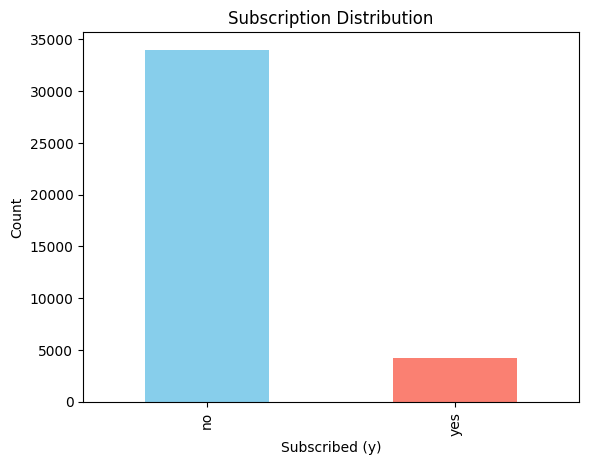

In [15]:
#visualize target variable distribution
bm['y'].value_counts().plot(kind='bar', color=['skyblue', 'salmon'])
plt.title("Subscription Distribution")
plt.xlabel("Subscribed (y)")
plt.ylabel("Count")
plt.show()


Text(0.5, 1.0, 'Job Distribution of Customers Who Subscribed')

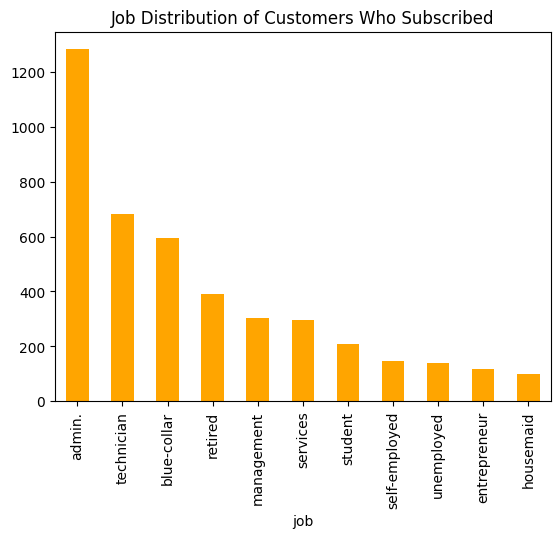

In [51]:
#visualize jobs of customers who subscribed to the term deposit
bm[bm['y'] == 'yes']['job'].value_counts().plot(kind='bar', color='orange')
plt.title("Job Distribution of Customers Who Subscribed")

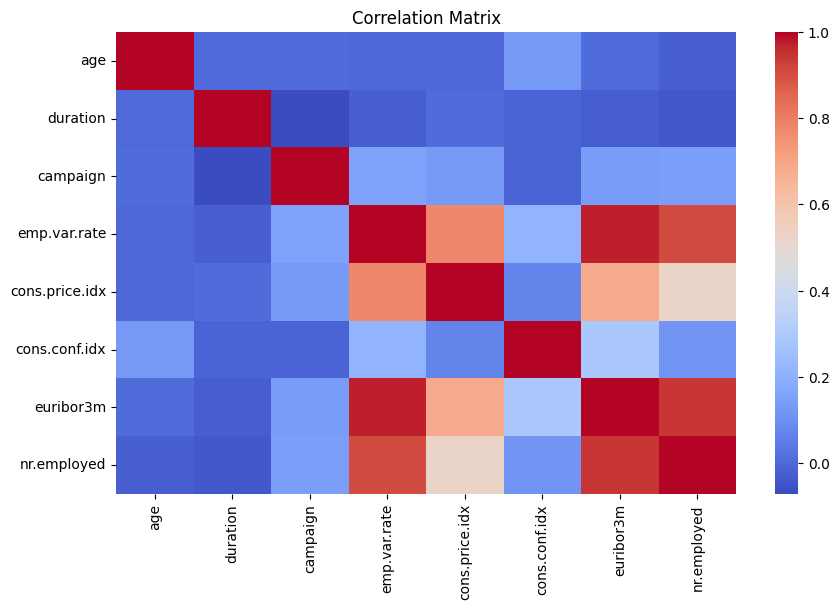

In [16]:
#correlation matrix
plt.figure(figsize=(10,6))
sns.heatmap(bm.corr(numeric_only=True), annot=False, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

In [21]:
bm.drop(["cons.price.idx"], axis=1)

,age,job,marital,education,housing,loan,contact,month,day_of_week,duration,campaign,emp.var.rate,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,telephone,may,mon,261,1,1.1,-36.4,4.857,5191.0,no
1,57,services,married,high.school,no,no,telephone,may,mon,149,1,1.1,-36.4,4.857,5191.0,no
2,37,services,married,high.school,yes,no,telephone,may,mon,226,1,1.1,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,telephone,may,mon,151,1,1.1,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,yes,telephone,may,mon,307,1,1.1,-36.4,4.857,5191.0,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41183,73,retired,married,professional.course,yes,no,cellular,nov,fri,334,1,-1.1,-50.8,1.028,4963.6,yes
41184,46,blue-collar,married,professional.course,no,no,cellular,nov,fri,383,1,-1.1,-50.8,1.028,4963.6,no
41185,56,retired,married,university.degree,yes,no,cellular,nov,fri,189,2,-1.1,-50.8,1.028,4963.6,no
41186,44,technician,married,professional.course,no,no,cellular,nov,fri,442,1,-1.1,-50.8,1.028,4963.6,yes


In [22]:
#display first few rows of the cleaned dataset
bm.head()

,age,job,marital,education,housing,loan,contact,month,day_of_week,duration,campaign,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,telephone,may,mon,261,1,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,no,no,telephone,may,mon,149,1,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,yes,no,telephone,may,mon,226,1,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,telephone,may,mon,151,1,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,yes,telephone,may,mon,307,1,1.1,93.994,-36.4,4.857,5191.0,no


In [23]:
#check number of column and rows
bm.dropna(inplace=True)

In [24]:
bm.describe()

,age,duration,campaign,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,38245.000000,38245.000000,38245.000000,38245.000000,38245.000000,38245.000000,38245.000000,38245.000000
mean,39.860871,258.207583,2.566662,0.082861,93.570313,-40.541164,3.623298,5167.432566
std,10.289488,259.792638,2.767473,1.565945,0.576367,4.623200,1.730226,71.760333
min,17.000000,0.000000,1.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.000000,102.000000,1.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.000000,180.000000,2.000000,1.100000,93.444000,-41.800000,4.857000,5191.000000
75%,47.000000,319.000000,3.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.000000,4918.000000,43.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


In [25]:
#define x and y
y = bm["y"]
x = bm.drop("y", axis=1)

#get dummies
x = pd.get_dummies(x, drop_first=True)


In [26]:
#map y to binary
y = y.map({'yes':1, 'no':0})

In [27]:
#train test split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

In [28]:
#build pipelines for xgboost
pipeline_xgb = Pipeline([
    ("scaler", StandardScaler()), 
    ("xgb", XGBClassifier(use_label_encoder=False, eval_metric='logloss'))])

In [29]:
#define parameter grid for xgboost
param_grid_xgb = {
    'xgb__n_estimators': [100, 200, 300],
    'xgb__max_depth': [3, 5, 7],
    'xgb__learning_rate': [0.01, 0.1, 0.2],
    'xgb__subsample': [0.6, 0.8, 1],
    'xgb__colsample_bytree': [0.6, 0.8, 1]
}

In [30]:
#perform randomized search for xgboost
randomxgb = RandomizedSearchCV(pipeline_xgb, param_distributions=param_grid_xgb, cv=5, scoring='neg_log_loss', random_state=42, n_jobs=-1)

In [31]:
#fit the model
randomxgb.fit(x_train, y_train)

c:\Users\oluwa\AppData\Local\Programs\Python\Python310\lib\site-packages\xgboost\training.py:200: UserWarning: [15:50:48] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,estimator,"Pipeline(step...=None, ...))])"
,param_distributions,"{'xgb__colsample_bytree': [0.6, 0.8, ...], 'xgb__learning_rate': [0.01, 0.1, ...], 'xgb__max_depth': [3, 5, ...], 'xgb__n_estimators': [100, 200, ...], ...}"
,n_iter,10
,scoring,'neg_log_loss'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [32]:
#predict and evaluate xgboost
y_pred_xgb = randomxgb.predict(x_test)
y_prob_xgb = randomxgb.predict_proba(x_test)[:, 1]

In [33]:
#evaluate xgboost
print("classification_report:", classification_report(y_test, y_pred_xgb))
print("accuracy_score: ", accuracy_score(y_test, y_pred_xgb))
print("f1_score: ", f1_score(y_test, y_pred_xgb))
print("Log Loss for XGBoost:", log_loss(y_test, y_prob_xgb))

classification_report:               precision    recall  f1-score   support

           0       0.94      0.96      0.95      6797
           1       0.65      0.54      0.59       852

    accuracy                           0.92      7649
   macro avg       0.80      0.75      0.77      7649
weighted avg       0.91      0.92      0.91      7649

accuracy_score:  0.9167211400183031
f1_score:  0.5924504158669226
Log Loss for XGBoost: 0.174279874653838


In [40]:
#evaluate xgboost model
y_pred_xgb = randomxgb.predict(x_test)
y_prob_xgb = randomxgb.predict_proba(x_test)[:, 1]
xgb = pd.DataFrame({'Prediction': y_pred_xgb[:38246], 'Probability': y_prob_xgb[:38246], 'Actual': y_test[:38246].values})
print(xgb)

      Prediction  Probability  Actual
0              0     0.018082       0
1              0     0.000488       0
2              0     0.005784       0
3              0     0.000402       0
4              0     0.000078       0
...          ...          ...     ...
7644           0     0.071689       0
7645           0     0.164618       0
7646           0     0.000863       0
7647           0     0.033670       0
7648           0     0.049359       1

[7649 rows x 3 columns]


In [44]:
#sort the dataframe by probability in descending order
top_50xgb = xgb.sort_values(by='Probability', ascending=False).head(50)
print(top_50xgb)

      Prediction  Probability  Actual
994            1     0.953685       0
3177           1     0.939799       0
3458           1     0.933533       1
3284           1     0.927188       1
6679           1     0.918814       1
4046           1     0.917705       0
378            1     0.913274       1
2007           1     0.904675       1
6379           1     0.895791       1
4195           1     0.890085       1
1510           1     0.889965       1
2664           1     0.887581       0
5667           1     0.886405       1
2434           1     0.884484       0
3641           1     0.883364       1
2311           1     0.882881       1
6498           1     0.879564       1
3568           1     0.878651       1
3594           1     0.872105       1
559            1     0.869404       1
1763           1     0.866471       1
5215           1     0.866223       1
614            1     0.864951       1
279            1     0.864612       1
4756           1     0.863350       1
1796        

In [ ]:
#based on the xgb model, the top 2 from

In [36]:
#use RandomForestClassifier
pipeline_rf = Pipeline([("scaler", StandardScaler()), ("rf", RandomForestClassifier())])

In [37]:
param_grid_rf = {
    'rf__bootstrap': [True, False],
    'rf__n_estimators': [50, 100, 200],
    'rf__max_depth': [None, 10, 20, 30],
    'rf__min_samples_split': [2, 5, 10],
    'rf__min_samples_leaf': [1, 2, 4]
}

In [38]:
randomized_rf = RandomizedSearchCV(pipeline_rf, param_distributions = param_grid_rf, cv=5, scoring= 'neg_log_loss', random_state=42)

In [39]:
randomized_rf.fit(x_train, y_train)

,estimator,Pipeline(step...lassifier())])
,param_distributions,"{'rf__bootstrap': [True, False], 'rf__max_depth': [None, 10, ...], 'rf__min_samples_leaf': [1, 2, ...], 'rf__min_samples_split': [2, 5, ...], ...}"
,n_iter,10
,scoring,'neg_log_loss'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [45]:
y_pred= randomized_rf.predict(x_test)
y_prob= randomized_rf.predict_proba(x_test)[:, 1]

In [46]:
rf = pd.DataFrame({'Prediction': y_pred[:38246], 'Probability': y_prob[:38246], 'Actual': y_test[:38246].values})
print(rf)

      Prediction  Probability  Actual
0              0     0.022660       0
1              0     0.001117       0
2              0     0.001638       0
3              0     0.002171       0
4              0     0.008045       0
...          ...          ...     ...
7644           0     0.013918       0
7645           0     0.156660       0
7646           0     0.007762       0
7647           0     0.006962       0
7648           0     0.052354       1

[7649 rows x 3 columns]


In [47]:
#sort values by probability
rf.sort_values(by='Probability', ascending=False)

,Prediction,Probability,Actual
4075,1,0.943485,1
5729,1,0.928708,1
6498,1,0.918004,1
766,1,0.909328,0
3265,1,0.896442,1
...,...,...,...
3607,0,0.000391,0
6779,0,0.000386,0
2662,0,0.000357,0
7381,0,0.000331,0


In [48]:
print("Best Hyperparameters:", randomized_rf.best_params_),
print("classification_report:\n", classification_report(y_test, y_pred)),
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred)),
print("f1_score:", f1_score(y_test, y_pred))
print("log_loss:", log_loss(y_test, y_prob))

Best Hyperparameters: {'rf__n_estimators': 200, 'rf__min_samples_split': 2, 'rf__min_samples_leaf': 4, 'rf__max_depth': 20, 'rf__bootstrap': False}
classification_report:
               precision    recall  f1-score   support

           0       0.94      0.97      0.95      6797
           1       0.65      0.47      0.55       852

    accuracy                           0.91      7649
   macro avg       0.79      0.72      0.75      7649
weighted avg       0.90      0.91      0.91      7649

Confusion Matrix:
 [[6580  217]
 [ 448  404]]
f1_score: 0.548540393754243
log_loss: 0.17687471360325246
